In [2]:
import sklearn
import sklearn.cluster
import sklearn.impute
import geopandas
import pandas
import shapely
import matplotlib.pyplot as plt

(20.0, 50.0)

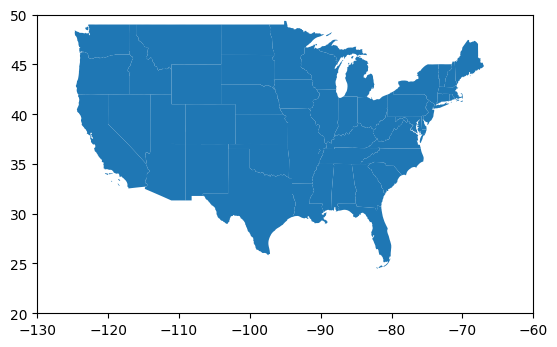

In [3]:
map = geopandas.read_file("cb_2024_us_state_20m.zip")
ax = map.plot()
ax.set_xlim(-130, -60)
ax.set_ylim(20, 50)

In [4]:
data = pandas.read_csv("SASUMMARY__ALL_AREAS_1998_2024.csv")
name = data[data["LineCode"] == 1.0]["GeoName"].reset_index(drop = True)
dpi = data[data["LineCode"] == 11.0]["2021"].reset_index(drop = True)
pce = data[data["LineCode"] == 12.0]["2021"].reset_index(drop = True)
rpp = data[data["LineCode"] == 13.0]["2021"].reset_index(drop = True)
sub = pandas.concat([name, dpi, pce, rpp], axis = 1)
sub.columns = ["NAME", "DPI", "PCE", "RPP"]
sub

,NAME,DPI,PCE,RPP
0,United States,56312,48529,100.000
1,Alabama,45720,39382,88.072
2,Alaska,60401,54127,104.808
3,Arizona,50761,46171,96.604
4,Arkansas,47688,39389,88.913
5,California,64407,55088,111.868
6,Colorado,62177,54342,102.815
7,Connecticut,68404,57033,102.828
8,Delaware,52022,50870,97.438
9,District of Columbia,82010,79370,111.586


In [5]:
combined = map.merge(sub, how = "left", on = "NAME")[["NAME", "geometry", "DPI", "PCE", "RPP"]]
combined.head(5)

,NAME,geometry,DPI,PCE,RPP
0,Texas,"POLYGON ((-106.62345 31.91403, -106.63011 31.9...",54369,45622,98.404
1,California,"MULTIPOLYGON (((-118.59397 33.46720, -118.4847...",64407,55088,111.868
2,Kentucky,"POLYGON ((-89.54443 36.57451, -89.47935 36.566...",46701,41199,89.256
3,Georgia,"POLYGON ((-85.60516 34.98468, -85.47434 34.983...",49473,43838,95.761
4,Wisconsin,"MULTIPOLYGON (((-86.93428 45.42115, -86.83575 ...",53747,45690,93.293


In [6]:
features = combined[["DPI", "PCE", "RPP"]]
impute = sklearn.impute.SimpleImputer(strategy = "mean")
impute.fit(features)
full = impute.transform(features)
scale = sklearn.preprocessing.StandardScaler()
scale.fit(full)
x = scale.transform(full)
x[0:5, :]

array([[-0.12815863, -0.32163916,  0.18217993],
       [ 1.25934028,  1.06870529,  2.11151877],
       [-1.18806515, -0.97127929, -1.12869289],
       [-0.80490646, -0.583669  , -0.19655169],
       [-0.21413436, -0.31165147, -0.55020649]])

(20.0, 50.0)

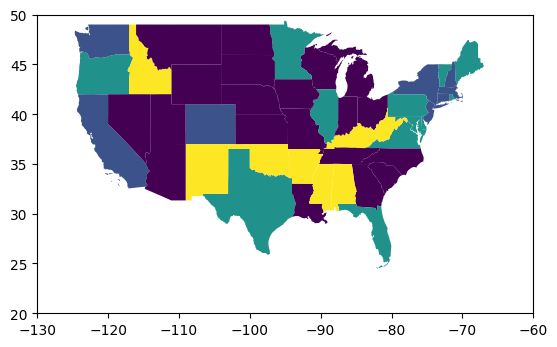

In [7]:
cluster = sklearn.cluster.AgglomerativeClustering(n_clusters = 5)
cluster.fit(x)
ax = map.plot(cluster.labels_)
ax.set_xlim(-130, -60)
ax.set_ylim(20, 50)

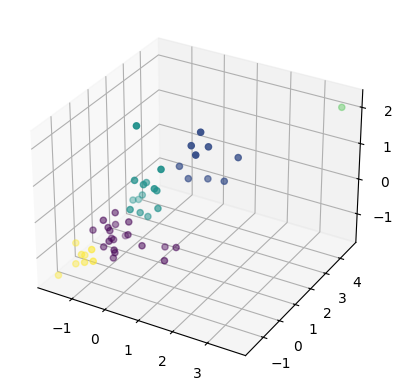

In [8]:
fig = plt.figure()
ax = fig.add_subplot(projection = "3d")
ax.scatter(x[:, 0], x[:, 1], x[:, 2], c = cluster.labels_)

(20.0, 50.0)

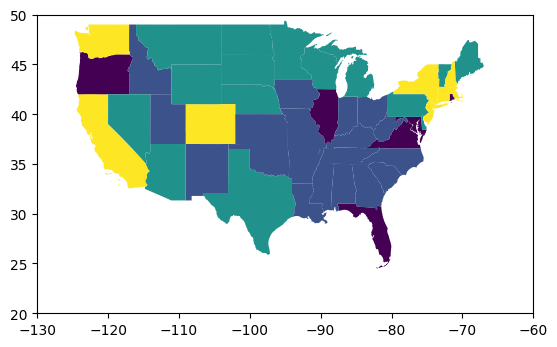

In [9]:
cluster = sklearn.cluster.KMeans(n_clusters = 5, n_init = 1)
cluster.fit(x)
ax = map.plot(cluster.labels_)
ax.set_xlim(-130, -60)
ax.set_ylim(20, 50)

(20.0, 50.0)

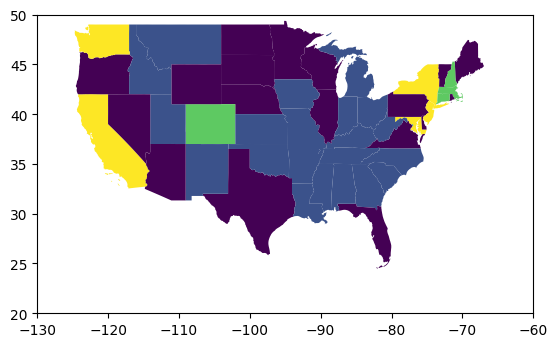

In [10]:
cluster.fit(x)
ax = map.plot(cluster.labels_)
ax.set_xlim(-130, -60)
ax.set_ylim(20, 50)

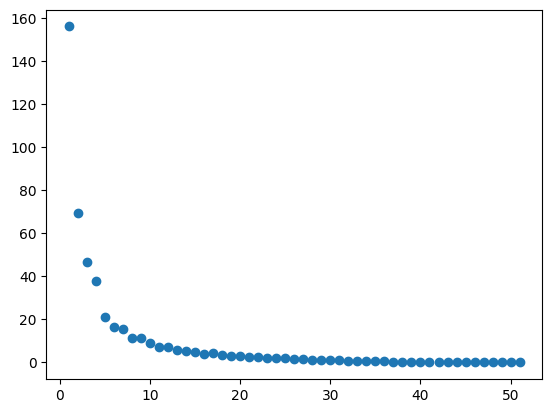

In [12]:
td = []
n = range(1, len(x))
for k in n:
    cluster = sklearn.cluster.KMeans(n_clusters = k, n_init = 1)
    cluster.fit(x)
    td.append(cluster.inertia_)
plt.scatter(n, td)